In [16]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

def plot_eer_curves(json_dir, max_event=650, model = None):
    """
    Plot avg_eer curves from all JSON files in a directory.
    - x-axis: number of events (scaled by different multipliers)
    - y-axis: avg_eer
    - The x-axis is capped at max_event.
    """

    json_dir = Path(json_dir)
    plt.figure(figsize=(8, 5))

    for json_file in json_dir.glob("*.json"):
        try:
            # Determine multiplier based on file name
            if "traj" in json_file.stem.lower():
                multiplier = 25.22
            elif "PeakClick" in json_file.stem:
                multiplier = 19.3
            else:
                multiplier = 1.0

            # Skip empty files
            if json_file.stat().st_size == 0:
                print(f"[SKIP] Empty file: {json_file.name}")
                continue

            # Load JSON data
            with open(json_file, "r") as f:
                data = json.load(f)

            # Compute coordinates
            n = np.arange(1, len(data["avg_eer"]) + 1)
            x_events = n * multiplier
            y_eer = np.array(data["avg_eer"])

            # Keep only values within max_event
            mask = x_events <= max_event
            x_events = x_events[mask]
            y_eer = y_eer[mask]

            plt.plot(x_events, y_eer, marker='o', linewidth=1.5, label=json_file.stem)

        except Exception as e:
            print(f"[ERROR] Failed to read {json_file.name}: {e}")
            continue

    plt.xlabel("Events", fontsize=12)
    plt.ylabel("Average EER", fontsize=12)
    plt.title(f"{model} (Max = {max_event})", fontsize=13, weight='bold')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [17]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_all_user_json_curves_single(json_dir, max_event=650, model = None):
    """
    Plot average EER (and AUC optionally) curves for all JSON files inside a folder.
    Each JSON file represents a model experiment, and each contributes one curve.

    Parameters
    ----------
    json_dir : str or Path
        Path to the folder containing JSON result files (e.g. 'Training/Results/train_all_user_1DCNN')
    max_event : int
        Maximum number of events to display on the x-axis
    """
    json_dir = Path(json_dir)
    plt.figure(figsize=(8, 5))

    for json_file in json_dir.glob("*.json"):
        try:
            # Set multiplier based on file name
            if "traj" in json_file.stem.lower():
                multiplier = 25.22
            elif "PeakClick" in json_file.stem:
                multiplier = 19.3
            else:
                multiplier = 1.0

            # Skip empty files
            if json_file.stat().st_size == 0:
                print(f"[SKIP] Empty file: {json_file.name}")
                continue

            # Load JSON data
            with open(json_file, "r") as f:
                data = json.load(f)

            # Aggregate per-user results
            user_eers = []
            ns = None
            for user, records in data.items():
                n_vals = []
                eers = []
                for k, v in records.items():
                    n_vals.append(v["n"])
                    eers.append(v["EER"])
                user_eers.append(eers)
                ns = n_vals  # same for all users

            # Compute average EER across users
            user_eers = np.array(user_eers)
            avg_eer = np.mean(user_eers, axis=0)

            # Compute event x-axis
            events = np.array(ns) * multiplier
            mask = events <= max_event
            events = events[mask]
            avg_eer = avg_eer[mask]

            plt.plot(events, avg_eer, marker='o', linewidth=1.8, label=json_file.stem)

        except Exception as e:
            print(f"[ERROR] Failed to process {json_file.name}: {e}")
            continue

    plt.xlabel("Events", fontsize=12)
    plt.ylabel("Average EER", fontsize=12)
    plt.title(f"{model} (Max = {max_event})", fontsize=13, weight='bold')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [18]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# color fixed
chunk_color_map = {
    "PeakClick": "tab:blue",
    "10": "tab:blue",
    "15": "tab:orange",
    "30": "tab:green",
    "60": "tab:red",
    "120": "tab:purple",
    "300": "tab:brown"
}

def plot_chunk_json_curves(json_dir, max_event=650, model=None):
    json_dir = Path(json_dir)
    plt.figure(figsize=(8, 5))

    for json_file in json_dir.glob("*.json"):
        try:
            name = json_file.stem

            if "PeakClick" in name:
                multiplier = 19.3
                chunk_key = "PeakClick"
            else:
                match = re.search(r"ChunkSize(\d+)", name)
                chunk_key = match.group(1) if match else None
                multiplier = float(chunk_key) if chunk_key else 1.0

            color = chunk_color_map.get(chunk_key, "black")

            with open(json_file, "r") as f:
                data = json.load(f)

            n = np.array(data["n"])
            avg_eer = np.array(data["avg_eer"])
            events = n * multiplier

            mask = events <= max_event
            events = events[mask]
            avg_eer = avg_eer[mask]

            plt.plot(events, avg_eer, marker='o', linewidth=1.8,
                     color=color, label=name)

        except Exception as e:
            print(f"[ERROR] Failed to process {json_file.name}: {e}")
            continue

    plt.xlabel("Events", fontsize=12)
    plt.ylabel("Average EER", fontsize=12)
    plt.title(f"{model} (Chunk Size Experiments)", fontsize=13, weight="bold")
    plt.grid(True, linestyle="--", alpha=0.6)

    # ---- chunk size ranking ----
    handles, labels = plt.gca().get_legend_handles_labels()

    def extract_size(label):
        if "PeakClick" in label:
            return -1
        m = re.search(r"ChunkSize(\d+)", label)
        return int(m.group(1)) if m else 999999

    sorted_pairs = sorted(zip(handles, labels), key=lambda x: extract_size(x[1]))
    sorted_handles, sorted_labels = zip(*sorted_pairs)

    plt.legend(sorted_handles, sorted_labels, fontsize=10)

    plt.tight_layout()
    plt.show()


**CNN**

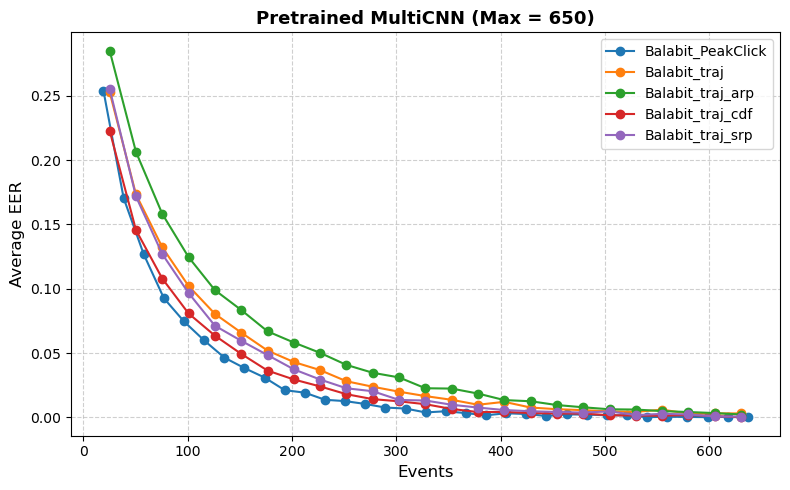

In [19]:
plot_eer_curves("Training/Results/train_multi_CNN", max_event=650, model="Pretrained MultiCNN")

**Chunking**

**CNN**

**X-Y Plot**

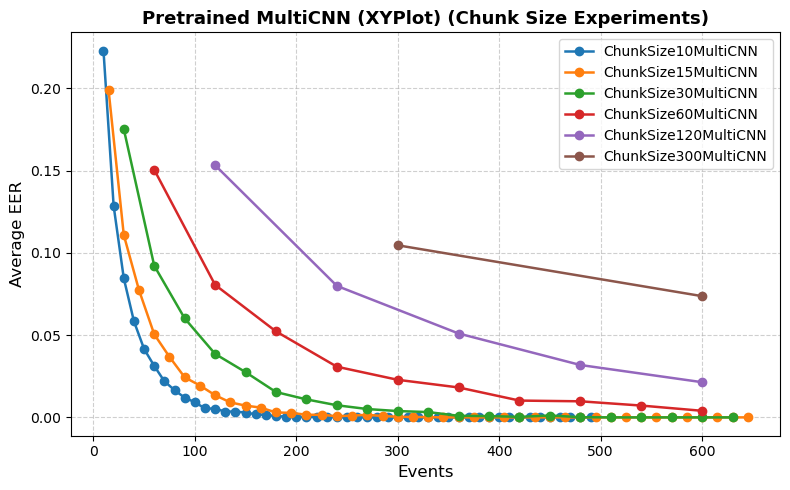

In [20]:
plot_chunk_json_curves("Visualization/Chunking/Balabit/train_multi_CNN/XYPlot", max_event=650, model="Pretrained MultiCNN (XYPlot)")

**SRP**

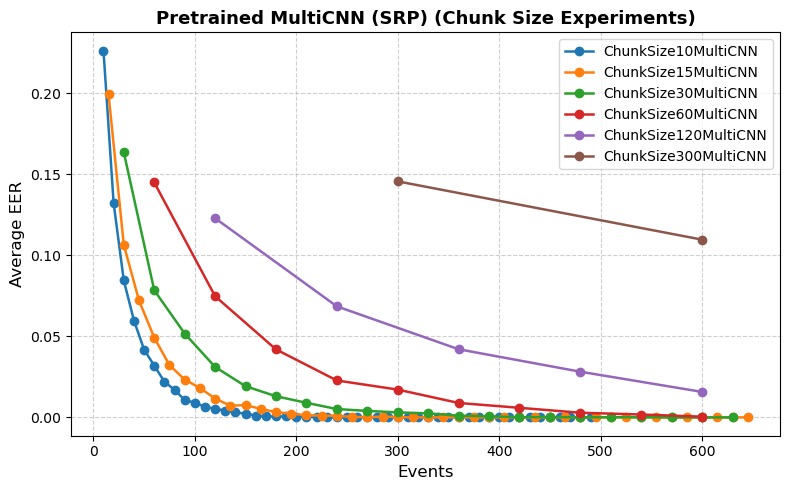

In [21]:
plot_chunk_json_curves("Visualization/Chunking/Balabit/train_multi_CNN/SRP", max_event=650, model="Pretrained MultiCNN (SRP)")

**CDF**

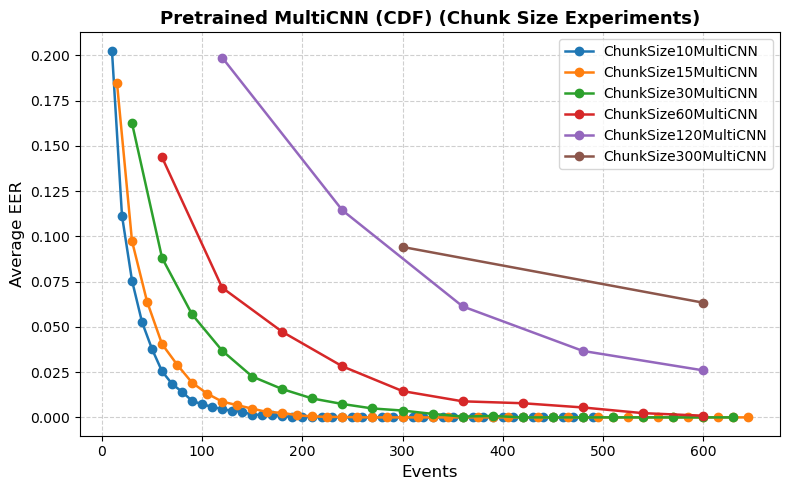

In [22]:
plot_chunk_json_curves("Visualization/Chunking/Balabit/train_multi_CNN/cdf", max_event=650, model="Pretrained MultiCNN (CDF)")

## ViT



**X-Y Plot**

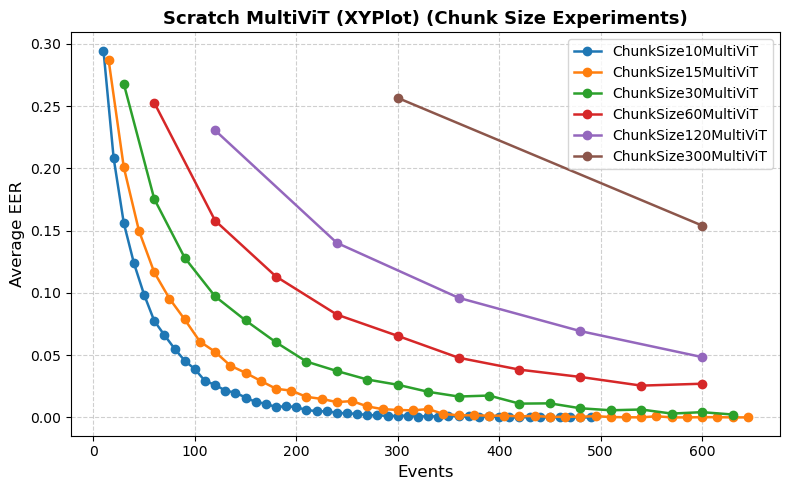

In [23]:
plot_chunk_json_curves("Visualization/Chunking/Balabit/train_multi_Scratch_ViT/XYPlot", max_event=650, model="Scratch MultiViT (XYPlot)")

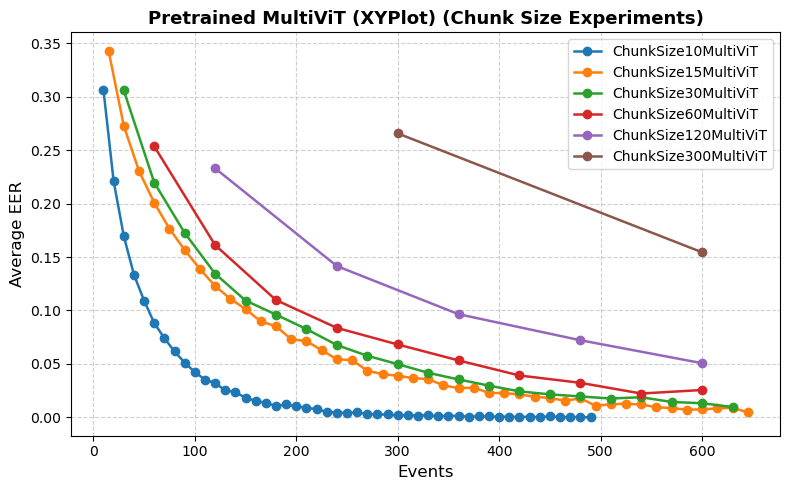

In [24]:
plot_chunk_json_curves("Visualization/Chunking/Balabit/train_multi_Pretrained_ViT/XYPlot", max_event=650, model="Pretrained MultiViT (XYPlot)")

**SRP**

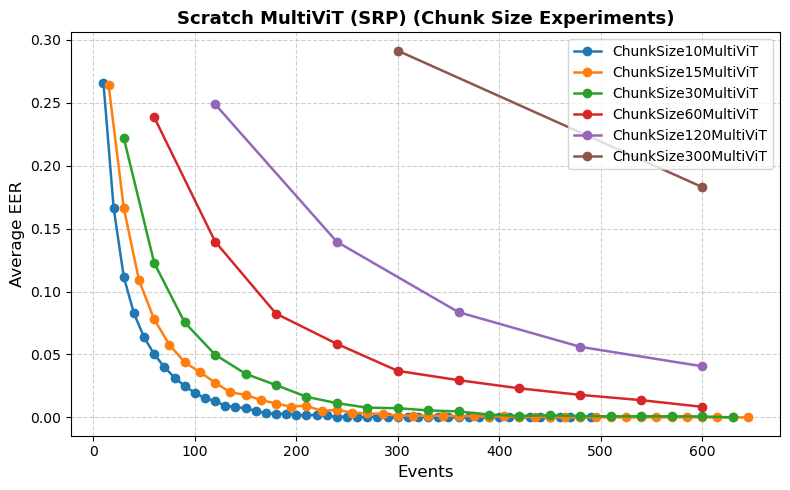

In [25]:
plot_chunk_json_curves("Visualization/Chunking/Balabit/train_multi_Scratch_ViT/SRP", max_event=650, model="Scratch MultiViT (SRP)")

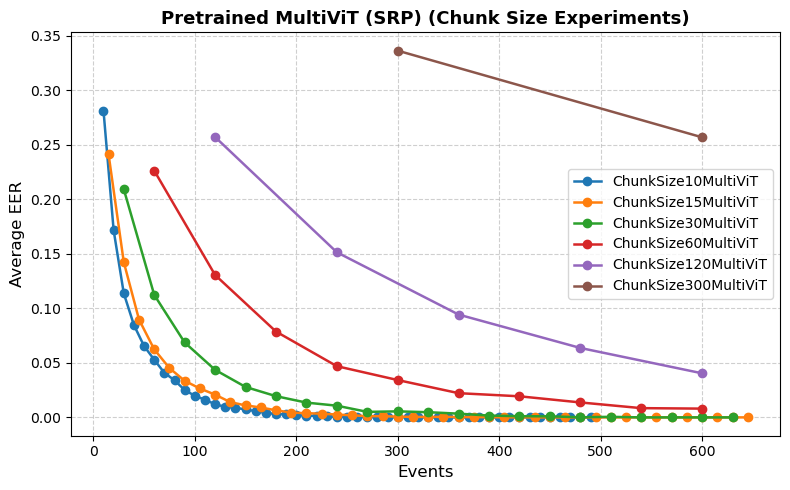

In [26]:
plot_chunk_json_curves("Visualization/Chunking/Balabit/train_multi_Pretrained_ViT/SRP", max_event=650, model="Pretrained MultiViT (SRP)")

**CDF**


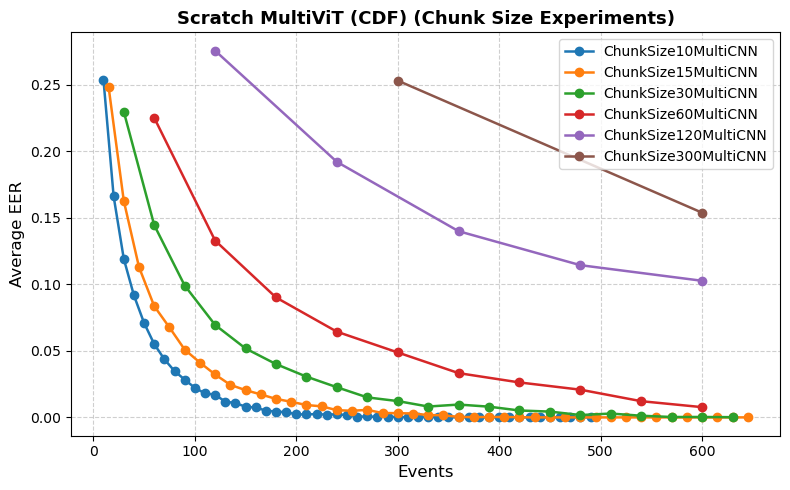

In [27]:
plot_chunk_json_curves("Visualization/Chunking/Balabit/train_multi_Scratch_ViT/cdf", max_event=650, model="Scratch MultiViT (CDF)")

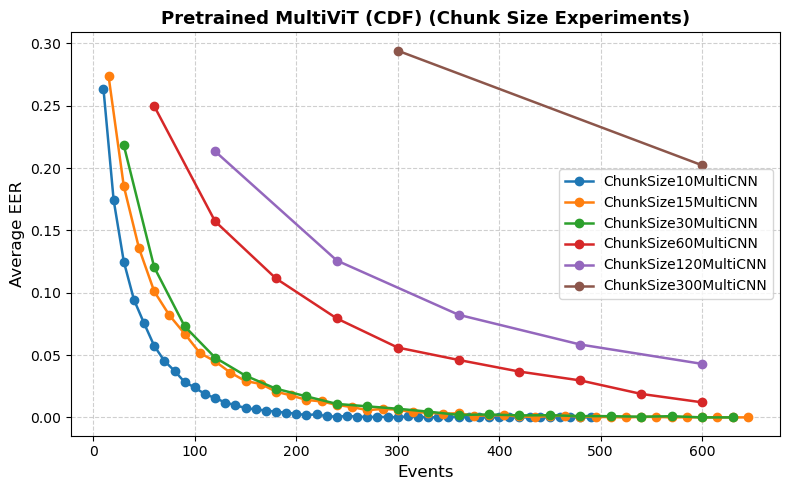

In [28]:
plot_chunk_json_curves("Visualization/Chunking/Balabit/train_multi_Pretrained_ViT/cdf", max_event=650, model="Pretrained MultiViT (CDF)")

## Others

**ViT**


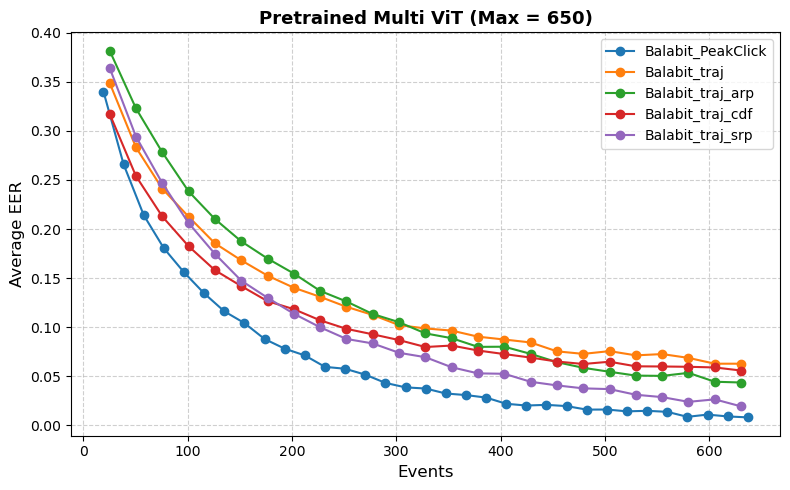

In [29]:
plot_eer_curves("Training/Results/train_multi_PretrainedViT", max_event=650, model="Pretrained Multi ViT")

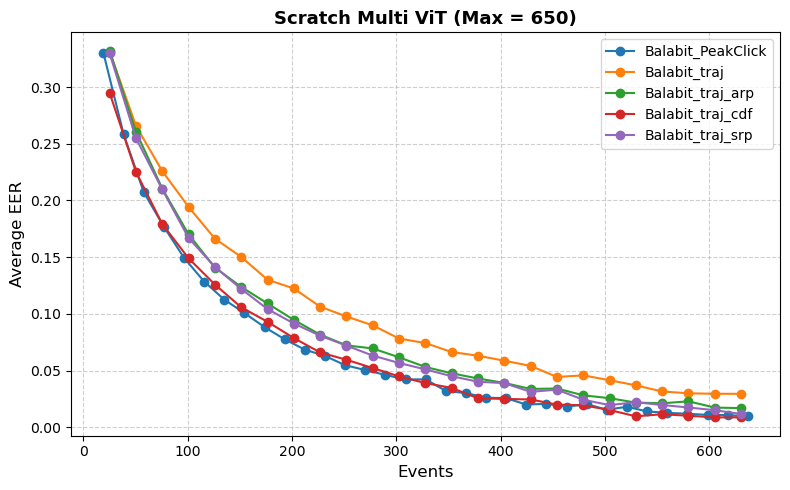

In [30]:
plot_eer_curves("Training/Results/train_multi_ScratchViT", max_event=650, model="Scratch Multi ViT")